# 02 · Exploración y hallazgos — GH-AW

Continúa el análisis de **[luchosqi/gh-aw-workflows](https://huggingface.co/datasets/luchosqi/gh-aw-workflows)**
a partir de las tablas ya revisadas en `01_descripcion_y_calidad.ipynb`.

Este notebook cubre:

1. Carga de los datos para el análisis
2. Distribución de archivos por repositorio
3. Exploración del frontmatter
4. Exploración del body
5. Relaciones entre variables
6. Hallazgos y limitaciones

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")


## 1. Carga de los datos para el análisis

Se cargan las tablas **ya preparadas** en el notebook 1 (`eda/data/processed/`), no las originales
del Hub — así este notebook depende solo de archivos en disco, nunca de variables que hayan
quedado en memoria de otra sesión.

| Tabla | Unidad analizada |
|---|---|
| `repositories` | un repositorio de GitHub |
| `workflow_files` | un archivo `.md` de GH-AW (incluye `body_word_count`, agregado en el notebook 1) |
| `frontmatter_entries` | una clave del frontmatter de un archivo (modelo EAV) |

In [2]:
PROCESSED_DIR = "data/processed"

repositories = pd.read_parquet(f"{PROCESSED_DIR}/repositories.parquet")
workflow_files = pd.read_parquet(f"{PROCESSED_DIR}/workflow_files.parquet")
frontmatter_entries = pd.read_parquet(f"{PROCESSED_DIR}/frontmatter_entries.parquet")

n_files = len(workflow_files)
for name, df in [("repositories", repositories), ("workflow_files", workflow_files),
                  ("frontmatter_entries", frontmatter_entries)]:
    print(f"{name:22s} {df.shape[0]:>7,} filas  x  {df.shape[1]} columnas")


repositories               370 filas  x  4 columnas
workflow_files           1,490 filas  x  6 columnas
frontmatter_entries     42,079 filas  x  5 columnas


## 2. Distribución de archivos por repositorio

Se cuenta cuántos archivos `.md` de GH-AW tiene cada repositorio (`workflow_files` agrupado por
`repo_id`).

In [3]:
files_por_repo = workflow_files.groupby("repo_id").size().rename("n_archivos")

resumen_files_por_repo = files_por_repo.agg(["min", "max", "mean", "median"]).rename({
    "min": "mínimo", "max": "máximo", "mean": "media", "median": "mediana"
})
resumen_files_por_repo.to_frame("n_archivos por repo")


,n_archivos por repo
mínimo,1.000000
máximo,299.000000
media,4.027027
mediana,1.000000


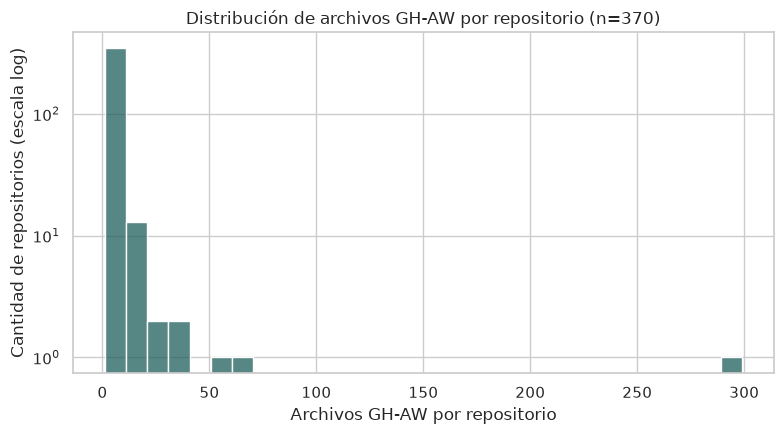

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(files_por_repo, bins=30, ax=ax, color="#1f5f5b")
ax.set_yscale("log")
ax.set_xlabel("Archivos GH-AW por repositorio")
ax.set_ylabel("Cantidad de repositorios (escala log)")
ax.set_title("Distribución de archivos GH-AW por repositorio (n=370)")
plt.tight_layout()
plt.show()


In [5]:
top_repos = (
    files_por_repo.sort_values(ascending=False)
    .head(8)
    .rename("n_archivos")
    .reset_index()
    .merge(repositories, on="repo_id")[["full_name", "n_archivos"]]
)
pct_un_archivo = (files_por_repo == 1).mean() * 100
print(f"Repositorios con exactamente 1 archivo GH-AW: {(files_por_repo == 1).sum()} de {len(files_por_repo)} ({pct_un_archivo:.1f}%)")
top_repos


Repositorios con exactamente 1 archivo GH-AW: 193 de 370 (52.2%)


,full_name,n_archivos
0,github/gh-aw,299
1,github/gh-aw-firewall,70
2,elastic/ai-github-actions,58
3,github/gh-aw-mcpg,36
4,microsoft/testfx,35
5,githubnext/ado-aw,26
6,githubnext/gh-aw-workshop,22
7,rysweet/amplihack,17


**Patrones observados:** la distribución está fuertemente concentrada y con cola larga a la
derecha — la mediana es 1 archivo por repositorio y más de la mitad de los repos (≈52%) tiene
exactamente uno, pero el máximo es 299. El caso extremo es **`github/gh-aw`** (el propio proyecto
que define GH-AW), seguido de `github/gh-aw-firewall` (70) y `elastic/ai-github-actions` (58): son
repositorios dedicados a construir o probar la propia herramienta, no adoptantes típicos, por lo
que conviene tenerlos presentes al leer promedios (la media, 4.0, está muy por encima de la
mediana justamente por estos pocos repos con decenas de archivos).

## 3. Exploración del frontmatter

Primero, cobertura general: para cada clave del frontmatter, cuántos archivos (de 1 490) la
declaran y qué porcentaje representa. Se muestran las 15 más frecuentes.

In [6]:
cobertura = frontmatter_entries["key_path"].value_counts().head(15)
cobertura_pct = (cobertura / n_files * 100).round(1)
tabla_cobertura = pd.DataFrame({"n_archivos": cobertura, "pct_archivos": cobertura_pct})
tabla_cobertura


,n_archivos,pct_archivos
key_path,,
description,1337,89.7
permissions.contents,1305,87.6
timeout-minutes,1090,73.2
tools.github.toolsets,1081,72.6
permissions.issues,1060,71.1
permissions.pull-requests,1045,70.1
tools.bash,874,58.7
network.allowed,825,55.4
on.schedule,770,51.7


Se exploran en detalle tres atributos: el **motor de IA** (`engine.id`), los **disparadores**
(`on.schedule` / `on.workflow_dispatch`) y los **permisos declarados** (`permissions.*`).

**Cómo se cuentan los campos con varios valores:** cuando una clave es una lista JSON (p. ej.
`tools.github.toolsets: [issues, repos, ...]`), cada elemento de la lista se cuenta una vez
mediante `explode()` — así "issues" cuenta como un uso del toolset `issues` sin importar cuántos
otros toolsets declare el mismo archivo.

### 3.1 Motor de IA (`engine.id`)

In [7]:
engine = frontmatter_entries.loc[frontmatter_entries["key_path"] == "engine.id", "value"]
n_con_engine = len(engine)

tabla_engine = engine.value_counts().rename("n_archivos").to_frame()
tabla_engine["pct_de_los_que_declaran"] = (tabla_engine["n_archivos"] / n_con_engine * 100).round(1)
tabla_engine


,n_archivos,pct_de_los_que_declaran
value,,
copilot,404,67.1
codex,88,14.6
claude,80,13.3
pi,11,1.8
opencode,4,0.7
aider,3,0.5
goose,3,0.5
gemini,3,0.5
pydantic-ai,2,0.3


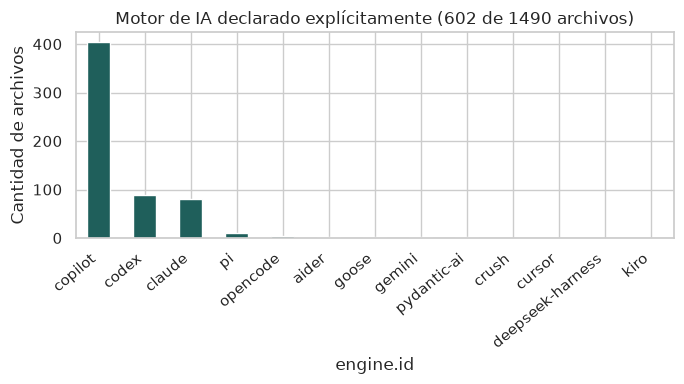

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
engine.value_counts().plot(kind="bar", ax=ax, color="#1f5f5b")
ax.set_xlabel("engine.id")
ax.set_ylabel("Cantidad de archivos")
ax.set_title(f"Motor de IA declarado explícitamente ({n_con_engine} de {n_files} archivos)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


**Interpretación:** solo el 40.4% de los archivos (602 de 1 490) declara `engine.id`
explícitamente; el resto usa el motor por defecto de GH-AW (no observable desde el frontmatter).
Entre los que sí lo declaran, **Copilot** domina con 67.1% (404/602), seguido de **Codex**
(14.6%) y **Claude** (13.3%); el resto de los motores (`pi`, `opencode`, `aider`, `goose`,
`gemini`, ...) son marginales, con 1–11 archivos cada uno.

### 3.2 Disparadores (`on.schedule` vs. `on.workflow_dispatch`)

In [9]:
ids_schedule = set(frontmatter_entries.loc[frontmatter_entries["key_path"] == "on.schedule", "file_id"])
ids_dispatch = set(frontmatter_entries.loc[frontmatter_entries["key_path"] == "on.workflow_dispatch", "file_id"])

categorias = {
    "Solo schedule": len(ids_schedule - ids_dispatch),
    "Solo workflow_dispatch": len(ids_dispatch - ids_schedule),
    "Ambos": len(ids_schedule & ids_dispatch),
    "Ninguno de los dos": n_files - len(ids_schedule | ids_dispatch),
}
tabla_triggers = pd.Series(categorias, name="n_archivos").to_frame()
tabla_triggers["pct_archivos"] = (tabla_triggers["n_archivos"] / n_files * 100).round(1)
tabla_triggers


,n_archivos,pct_archivos
Solo schedule,145,9.7
Solo workflow_dispatch,125,8.4
Ambos,625,41.9
Ninguno de los dos,595,39.9


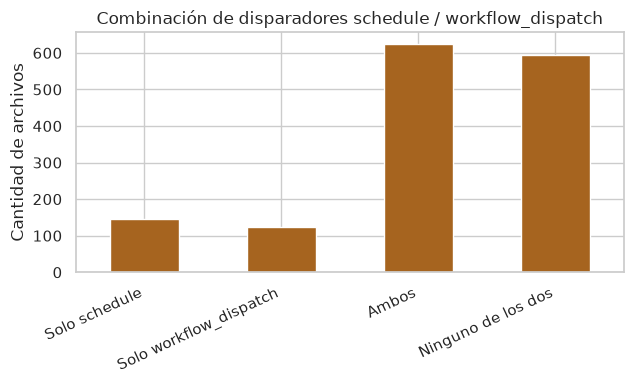

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
tabla_triggers["n_archivos"].plot(kind="bar", ax=ax, color="#a6641f")
ax.set_ylabel("Cantidad de archivos")
ax.set_title("Combinación de disparadores schedule / workflow_dispatch")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


**Interpretación:** el 42% de los archivos (625/1490) combina ambos disparadores —se ejecutan
por cron y también permiten lanzarlos a mano—, un patrón típico de agentes de mantenimiento
recurrente con la opción de correrlos bajo demanda para depurar. Un 40% (595) no declara ninguno
de los dos, lo que sugiere otros disparadores (`on.issues`, `on.pull_request`, `on.push`,
reacciones a comentarios, etc., visibles en la tabla de cobertura de la sección 3).

### 3.3 Permisos declarados (`permissions.*`)

In [11]:
permisos = frontmatter_entries[
    frontmatter_entries["key_path"].str.startswith("permissions.")
    & (frontmatter_entries["key_path"] != "permissions.all")
].copy()
permisos["campo"] = permisos["key_path"].str.removeprefix("permissions.")

tabla_permisos = pd.crosstab(permisos["campo"], permisos["value"]).sort_values("read", ascending=False)
tabla_permisos["pct_archivos"] = ((tabla_permisos.sum(axis=1)) / n_files * 100).round(1)
tabla_permisos.head(10)


value,read,write,pct_archivos
campo,,,
contents,1303,2,87.6
issues,1057,3,71.1
pull-requests,1043,2,70.1
actions,415,0,27.9
discussions,102,0,6.8
security-events,51,0,3.4
checks,50,0,3.4
statuses,28,0,1.9
models,22,0,1.5


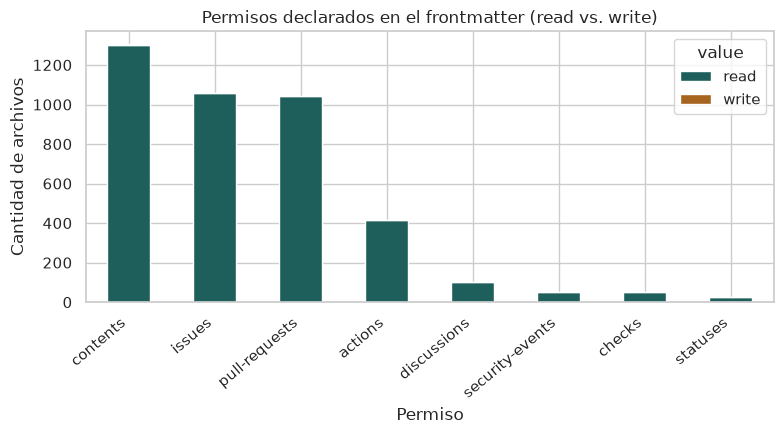

In [12]:
top_permisos = tabla_permisos.head(8).drop(columns="pct_archivos")
fig, ax = plt.subplots(figsize=(8, 4.5))
top_permisos.plot(kind="bar", stacked=True, ax=ax, color=["#1f5f5b", "#a6641f"])
ax.set_ylabel("Cantidad de archivos")
ax.set_xlabel("Permiso")
ax.set_title("Permisos declarados en el frontmatter (read vs. write)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


**Interpretación:** `contents`, `issues` y `pull-requests` son los permisos más declarados
(70–88% de los archivos), y son casi exclusivamente de **lectura**: por ejemplo
`permissions.contents` es `read` en 1303 archivos y `write` en solo 2. Esto refleja el principio
de mínimo privilegio que promueve GH-AW — los agentes leen contexto del repositorio y casi nunca
escriben directamente; cuando necesitan crear un issue o comentar, suelen hacerlo a través del
mecanismo `safe-outputs` (visible en la tabla de cobertura como `safe-outputs.create-issue.*`)
en lugar de permisos de escritura directos.

## 4. Exploración del body

Longitud en palabras del body Markdown de cada archivo (columna `body_word_count`, calculada en
el notebook 1 con `str.split()`).

In [13]:
resumen_wc = workflow_files["body_word_count"].agg(["min", "max", "mean", "median"]).rename({
    "min": "mínimo", "max": "máximo", "mean": "media", "median": "mediana"
})
n_vacios = (workflow_files["body_word_count"] == 0).sum()
print(f"Archivos con body vacío (0 palabras): {n_vacios}")
resumen_wc.to_frame("palabras en el body")


Archivos con body vacío (0 palabras): 0


,palabras en el body
mínimo,3.000000
máximo,15217.000000
media,1054.602685
mediana,748.500000


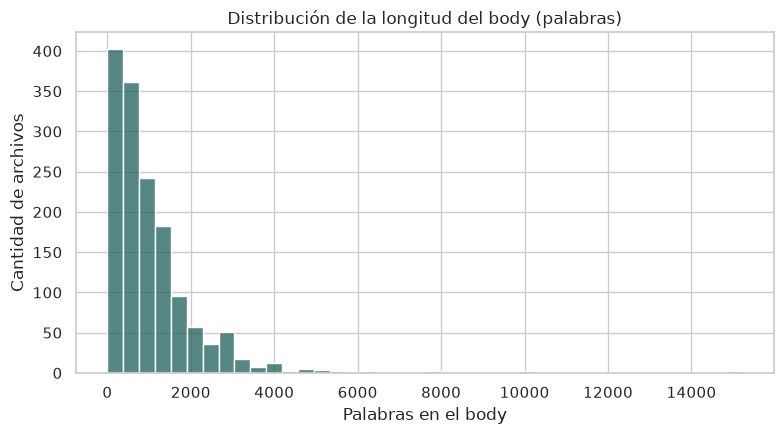

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(workflow_files["body_word_count"], bins=40, ax=ax, color="#1f5f5b")
ax.set_xlabel("Palabras en el body")
ax.set_ylabel("Cantidad de archivos")
ax.set_title("Distribución de la longitud del body (palabras)")
plt.tight_layout()
plt.show()


In [15]:
con_repo = workflow_files.merge(repositories, on="repo_id")
extremos = pd.concat([
    con_repo.nlargest(3, "body_word_count").assign(caso="más largos"),
    con_repo.nsmallest(3, "body_word_count").assign(caso="más cortos"),
])[["caso", "full_name", "path", "body_word_count"]]
extremos


,caso,full_name,path,body_word_count
36,más largos,dotnet/maui,.github/workflows/ci-status-fix-net11.md,15217
35,más largos,dotnet/maui,.github/workflows/ci-status-fix.md,15175
1273,más largos,Azure/terraform-azurerm-avm-res-resources-reso...,.github/workflows/issue-triage.md,10191
555,más cortos,pydantic/pydantic-ai,.github/workflows/pydantic-ai-bug-hunter.md,3
557,más cortos,pydantic/pydantic-ai,.github/workflows/pydantic-ai-docs-drift.md,3
560,más cortos,pydantic/pydantic-ai,.github/workflows/pydantic-ai-provider-mapping...,3


**Interpretación:** la mediana (748.5 palabras) muy por debajo de la media (1054.6) confirma
una distribución con cola larga a la derecha — no hay bodies vacíos, pero sí una minoría de
prompts extensos. Los más largos superan las 9 500 palabras y aparecen en repos grandes de
infraestructura (`dotnet/maui`, `dotnet/aspnetcore`, `Azure/terraform-azurerm-avm-*`), donde el
agente necesita instrucciones detalladas sobre convenciones del proyecto. Los más cortos (3
palabras) aparecen todos en `pydantic/pydantic-ai`: son plantillas mínimas que probablemente
delegan el detalle en archivos importados vía la clave `imports` (presente en 40.7% de los
archivos, según la tabla de cobertura).

## 5. Relaciones entre variables

### Pregunta 1 — ¿La longitud del body varía según el motor de IA declarado?

**Variables:** `engine.id` (`frontmatter_entries`) y `body_word_count` (`workflow_files`).
**Tablas combinadas:** `frontmatter_entries` + `workflow_files`, mediante `file_id`.

In [16]:
engine_por_archivo = frontmatter_entries.loc[
    frontmatter_entries["key_path"] == "engine.id", ["file_id", "value"]
].rename(columns={"value": "engine"})

wc_por_engine = workflow_files.merge(engine_por_archivo, on="file_id", how="inner")

# nos quedamos con los motores que aparecen en al menos 10 archivos, para que el resumen sea legible
motores_frecuentes = wc_por_engine["engine"].value_counts()
motores_frecuentes = motores_frecuentes[motores_frecuentes >= 10].index
wc_por_engine_top = wc_por_engine[wc_por_engine["engine"].isin(motores_frecuentes)]

resumen_engine_wc = (
    wc_por_engine_top.groupby("engine")["body_word_count"]
    .agg(n="count", mediana="median", media="mean")
    .sort_values("mediana", ascending=False)
    .round(1)
)
resumen_engine_wc


,n,mediana,media
engine,,,
pi,11,1243.0,1336.7
copilot,404,701.5,1111.1
claude,80,678.0,968.0
codex,88,665.0,977.8


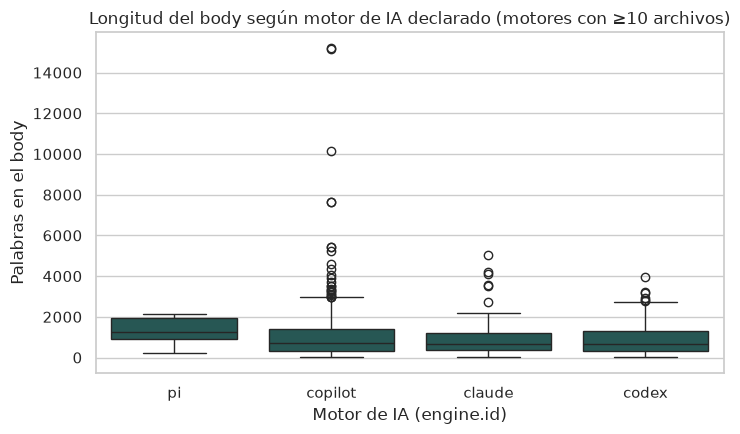

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(
    data=wc_por_engine_top, x="engine", y="body_word_count", ax=ax,
    order=resumen_engine_wc.index, color="#1f5f5b",
)
ax.set_xlabel("Motor de IA (engine.id)")
ax.set_ylabel("Palabras en el body")
ax.set_title("Longitud del body según motor de IA declarado (motores con ≥10 archivos)")
plt.tight_layout()
plt.show()


**Respuesta:** sí varía, aunque no en la dirección más obvia. Entre los motores con al menos
10 archivos, `pi` tiene la mediana más alta (1243 palabras, aunque con solo 11 archivos, poco
representativo), seguido por **`copilot`** (701.5) — el motor más frecuente y, sorprendentemente,
el de mediana más alta entre los tres principales — mientras que `claude` (678) y `codex` (665)
quedan algo por debajo. Es decir, no se observa que declarar un motor "más conversacional" como
Claude o Codex implique prompts más largos que el motor por defecto de GitHub (Copilot); la
diferencia entre estos tres es, además, moderada frente a la dispersión dentro de cada grupo
(ver la caja de cada motor en el gráfico).

In [18]:
bucket = files_por_repo.apply(lambda n: "1 archivo" if n == 1 else "2+ archivos").rename("bucket_repo")

wf_bucket = (
    workflow_files.merge(bucket, on="repo_id")
    .assign(tiene_schedule=lambda d: d["file_id"].isin(ids_schedule))
)

tabla_bucket = (
    wf_bucket.groupby("bucket_repo")["tiene_schedule"]
    .agg(n_archivos="count", n_con_schedule="sum")
    .assign(pct_con_schedule=lambda d: (d["n_con_schedule"] / d["n_archivos"] * 100).round(1))
)
tabla_bucket


,n_archivos,n_con_schedule,pct_con_schedule
bucket_repo,,,
1 archivo,193,76,39.4
2+ archivos,1297,694,53.5


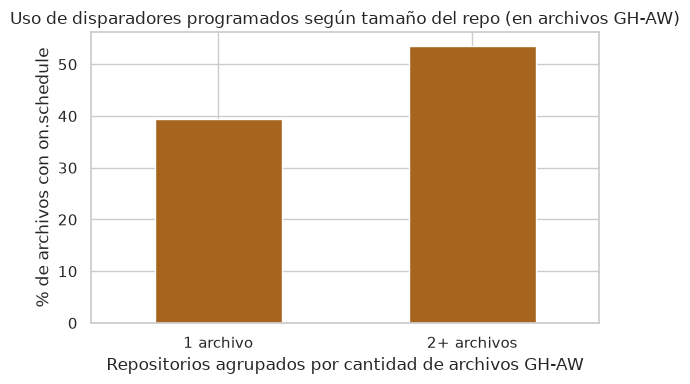

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
tabla_bucket["pct_con_schedule"].plot(kind="bar", ax=ax, color="#a6641f")
ax.set_ylabel("% de archivos con on.schedule")
ax.set_xlabel("Repositorios agrupados por cantidad de archivos GH-AW")
ax.set_title("Uso de disparadores programados según tamaño del repo (en archivos GH-AW)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Respuesta:** al revés de lo esperado: los repositorios con **2 o más archivos GH-AW** usan
`on.schedule` en una proporción mayor (53.5% de sus archivos) que los repositorios con un único
archivo (39.4%). Una lectura posible es que los repos que ya invirtieron en varios workflows
agénticos tienden a ser adopciones más maduras de GH-AW, con agentes de mantenimiento periódico
(reportes, triage) ejecutándose por cron, mientras que muchos de los repos con un solo archivo
lo usan para un caso puntual disparado manualmente o por un evento específico (`on.issues`,
`on.pull_request`), sin necesidad de una ejecución programada.

## 6. Hallazgos y limitaciones

### Hallazgos

1. **La adopción de GH-AW está muy concentrada en pocos repositorios grandes.** Más de la mitad
   de los repos (52%) tiene un solo archivo GH-AW, pero el repositorio `github/gh-aw` —el propio
   proyecto de la herramienta— concentra 299 de los 1490 archivos (20%). *(Sección 2.)*
2. **La mayoría de los workflows opera con permisos de solo lectura.** `permissions.contents`,
   `issues` y `pull-requests` son los permisos más declarados (70–88% de los archivos) y son
   `write` en menos del 0.3% de los casos, consistente con el patrón `safe-outputs` de GH-AW para
   acciones de escritura. *(Sección 3.3.)*
3. **El motor de IA declarado no es un buen predictor de la extensión del prompt.** Entre los
   motores con uso significativo, `copilot` (el más común, 404 archivos) tiene una mediana de
   701.5 palabras, apenas por encima de `claude` (678) y `codex` (665) — las diferencias son
   pequeñas frente a la dispersión dentro de cada grupo. *(Sección 5, Pregunta 1.)*
4. **Los repos con más archivos GH-AW usan disparadores programados con más frecuencia.** El
   53.5% de los archivos en repos con 2 o más workflows declara `on.schedule`, frente a 39.4% en
   repos con un solo archivo — consistente con adopciones más maduras que automatizan tareas
   recurrentes. *(Sección 5, Pregunta 2.)*

### Limitaciones

- **Cobertura del dataset:** solo incluye repositorios ya identificados como usuarios de GH-AW en
  una tarea previa (Tarea 2); no representa la totalidad de GitHub ni necesariamente la
  distribución actual de adopción, que puede haber cambiado desde entonces.
- **Motor de IA por defecto no observable:** el 59.6% de los archivos no declara `engine.id`
  explícitamente. No es posible saber, solo con este dataset, qué motor terminan usando esos
  archivos — el análisis de la sección 5.1 se limita a quienes lo declaran.
- **EAV y campos multivaluados:** el modelo entidad-atributo-valor del frontmatter preserva
  cualquier clave, pero requiere decisiones de conteo (p. ej. `explode()` para listas) que pueden
  no coincidir con cómo otro análisis agregaría los mismos datos — se documentó el criterio
  usado en la sección 3.
- **Outliers con alto peso en promedios:** repos como `github/gh-aw` (299 archivos) inflan la
  media de archivos-por-repo y aparecen sobrerrepresentados en cualquier conteo por archivo; las
  medianas y los desgloses por bucket (sección 5, Pregunta 2) buscan mitigar ese efecto, pero no
  lo eliminan del todo.